In [1]:
from FPSim2.scripts.create_fpsim2_fp_db import create_db_file_parallel
import dask.dataframe as dd
import os
from FPSim2 import FPSim2Engine
import pandas as pd
import pickle as pk
import datamol as dm
from rdkit import Chem
from rdkit.DataStructs import ExplicitBitVect
from FPSim2.io.chem import build_fp, load_molecule, process_fp
import numpy as np
from pathlib import Path
from collections import defaultdict
import FPSim2
import rdkit

In [2]:
FPSim2.__version__, rdkit.__version__, dm.__version__

('0.7.3', '2025.09.3', '0.12.5')

In [3]:
data = dd.read_parquet("test1/*.parquet")
len(data)

4175752

In [4]:
create_db_file_parallel(
    smi_file="test.smi", 
    out_file="pattern_screenout.h5", 
    fp_type="RDKitPattern", 
    fp_params={}, 
    full_sanitization=False, 
    num_processes=4
)

In [9]:
os.path.getsize('pattern_screenout.h5') /1024**3 * 134_100_000_000/4175752

22128.288529745536

### test search

In [3]:
def load_pickle(path, default):
    if Path(path).exists():
        with open(path, "rb") as f:
            return pk.load(f)
    return default

In [4]:
def load_query(
    query,
    full_sanitization: bool = True,
    fp_type: str = "Morgan",
    fp_params: dict = {'radius': 2, 'fpSize': 1024},
):
    """Loads the query fingerprint from SMILES, molblock, InChI or ExplicitBitVect fingerprint.

    Parameters
    ----------
    query : Union[str, ExplicitBitVect]
        SMILES, InChi, molblock or fingerprint as ExplicitBitVect.

    Returns
    -------
    query : numpy array
        Numpy array query molecule.
    """

    if isinstance(query, ExplicitBitVect):
        fp = process_fp(query, 0)
    elif isinstance(query, Chem.Mol):
        fp = build_fp(query, fp_type, fp_params, 0)
    else:
        rdmol = load_molecule(query, full_sanitization=full_sanitization)
        fp = build_fp(rdmol, fp_type, fp_params, 0)
    return np.array(fp, dtype=np.uint64)

In [18]:
with open("../../../top_100.smi") as f:
    smiles = [x.strip() for x in f.readlines()]
with open("../../../TPP_prot.smi") as f:
    smiles2 = [x.strip() for x in f.readlines()]
smiles2

['Cc1ncc(C[n+]2csc(CCO[P@@](=O)([O-])O[P@@](=O)([O-])O)c2C)c(N)n1']

In [22]:
for sm in smiles:
    fp1 = load_query(sm, full_sanitization=False)
    fp2 = load_query(sm, full_sanitization=True)
    if not np.array_equal(fp1, fp2):
        print(sm)

In [11]:
def read_search_results(top_k: None | int = None, 
                        search_type: str = "similarity",
                        outpath: Path = Path("search_results"), num=None) -> dict[str, list[tuple[int, int]]]:
    
    if not outpath.exists():
        raise FileNotFoundError("The folder for the search results doesn't exists, check the folder")
    res = {}
    print(f"Reading search results from {outpath}...")
    search_results = defaultdict(list)
    for x in outpath.glob("*.pkl"):
        if num and int(x.stem.split("_")[-1]) != num: continue
        with open(x, "rb") as js:
            res = pk.load(js) # A dictionary of {query: search results}
        for query, item in res.items():
            search_results[query].extend(item)
    if search_type == "similarity":
        for query, item in search_results.items():
            sort_item = sorted(item, key=lambda x: x[1], reverse=True)
            if top_k is not None:
                sort_item = sort_item[:top_k]
            res[query] = sort_item
        return res
    
    return {query: sorted(item) for query, item in search_results.items()}

def read_separate_results(outpath: Path = Path("search_results"), num=None) -> dict[str, list[tuple[int, int]]]:
    
    if not Path(outpath).exists():
        raise FileNotFoundError("The folder for the search results doesn't exists, check the folder")
    res = {}
    print(f"Reading search results from {outpath}...")
    search_results = {}
    for x in Path(outpath).glob("*.pkl"):
        num = int(x.stem.split("_")[-1])
        with open(x, "rb") as js:
            res = pk.load(js) # A dictionary of {query: search results}
        for query, item in res.items():
            
            search_results[num] = item

    return search_results
    

In [12]:
read_separate_results("/home/ruite/Projects/AI factory/Drug database/TPP_prot_tmp_chunks_search_results")

Reading search results from /home/ruite/Projects/AI factory/Drug database/TPP_prot_tmp_chunks_search_results...


{1000: [(2409573550, 0.60317462682724), (2413491029, 0.5)],
 1200: [],
 2000: [(525479218, 0.59375), (523585208, 0.5633803009986877)],
 1500: [(1467976540, 0.5507246255874634)]}

In [19]:
search_1 = read_separate_results(outpath=Path("/home/ruite/Projects/AI factory/Drug database/TPP_prot_tmp_chunks_search_results_prev"))
search_1[2000]

Reading search results from /home/ruite/Projects/AI factory/Drug database/TPP_prot_tmp_chunks_search_results_prev...


[(525479218, 0.59375), (523585208, 0.5633803009986877)]

In [143]:
search_2 = read_search_results(1000, outpath=Path("/home/ruite/Projects/AI factory/Drug database/TPP_prot_tmp_chunks_search_results"))
search_2["Cc1ncc(C[n+]2csc(CCO[P@@](=O)([O-])O[P@@](=O)([O-])O)c2C)c(N)n1"]

Reading search results from /home/ruite/Projects/AI factory/Drug database/TPP_prot_tmp_chunks_search_results...


[(1334291592, 0.6896551847457886),
 (1086440841, 0.6779661178588867),
 (850795222, 0.6499999761581421),
 (1030369735, 0.6499999761581421),
 (823458741, 0.6499999761581421),
 (925167662, 0.6333333253860474),
 (909672834, 0.6290322542190552),
 (1095089329, 0.6229507923126221),
 (841842032, 0.6229507923126221),
 (788812594, 0.6166666746139526),
 (908740790, 0.6129032373428345),
 (1096223919, 0.5932203531265259),
 (1198251423, 0.5873016119003296),
 (902262300, 0.5873016119003296),
 (1258885897, 0.5873016119003296),
 (1103797325, 0.5806451439857483),
 (807660925, 0.5806451439857483),
 (945906722, 0.578125),
 (718526497, 0.5483871102333069),
 (947579333, 0.5384615659713745),
 (1158486299, 0.5223880410194397)]

In [97]:
search_3 = read_separate_results(100000, outpath=Path("/home/ruite/Projects/AI factory/Drug database/previous/TPP_prot_search_results_full"))
search_3

Reading search results from /home/ruite/Projects/AI factory/Drug database/previous/TPP_prot_search_results_full...


{71: [(3343643052, 0.6984127163887024),
  (3536557507, 0.625),
  (3448164000, 0.6212121248245239),
  (3374056769, 0.6212121248245239),
  (3541277668, 0.6153846383094788),
  (3266359346, 0.611940324306488),
  (3260318941, 0.6060606241226196),
  (3438499804, 0.6060606241226196),
  (3251504839, 0.5970149040222168),
  (3339903107, 0.59375),
  (3375019758, 0.59375),
  (3518645228, 0.5882353186607361),
  (3317379865, 0.5882353186607361),
  (3277863369, 0.5882353186607361),
  (3359019992, 0.5882353186607361),
  (3209736497, 0.5857142806053162),
  (3450984183, 0.5846154093742371),
  (3387207630, 0.5797101259231567),
  (3485671668, 0.5797101259231567),
  (3262544558, 0.5797101259231567),
  (3221767424, 0.5797101259231567),
  (3446285170, 0.5797101259231567),
  (3216990737, 0.5797101259231567),
  (3471304490, 0.5797101259231567),
  (3214501056, 0.577464759349823),
  (3221642958, 0.577464759349823),
  (3512270618, 0.5757575631141663),
  (3259641707, 0.5757575631141663),
  (3244446267, 0.571428596

### Search analogues

In [84]:
fp_filename = 'fp_db.h5'
fpe = FPSim2Engine(fp_filename)
search = {}
tanimoto = {}
query = 'CN(Cc1ccco1)C(=O)c2ccon2'
results = fpe.top_k(query, k=100, threshold=0.6, metric='tanimoto', n_workers=4, full_sanitization=False)

search[query] = [(int(x["mol_id"]), float(x["coeff"])) for x in results]
tanimoto[query] = pd.Series({int(x[0]): float(x[1]) for x in results}).rename("Tanimoto")

search

{'CN(Cc1ccco1)C(=O)c2ccon2': []}

In [ ]:
with open(f"search_res.pkl", "wb") as js:
    pk.dump(search, js)

In [12]:
with open("search_res.pkl", "rb") as js:
    res = pk.load(js) 
for query, item in res.items():
    print(item[:10])

[(1, 1.0), (796, 0.6904761791229248), (12, 0.6511628031730652), (2, 0.6499999761581421), (3854, 0.6363636255264282), (3821, 0.6279069781303406), (17841, 0.6222222447395325), (3732, 0.6136363744735718), (795, 0.6136363744735718), (2949, 0.6136363744735718)]


### Search substructure

In [2]:
from rdkit import Chem, RDLogger
from rdkit.Chem.MolStandardize import rdMolStandardize
import pandas as pd
import datamol as dm
from dask.distributed import Client
from functools import partial

In [ ]:
client = Client(n_workers=4)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 4
Total threads: 8,Total memory: 31.08 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:33195,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:46723,Total threads: 2
Dashboard: http://127.0.0.1:42505/status,Memory: 7.77 GiB
Nanny: tcp://127.0.0.1:36237,


In [9]:
fp_filename = "pattern_screenout.h5"
fpe = FPSim2Engine(fp_filename, in_memory_fps=False)

query = 'c1ccc(S(=O)(=O)N)cc1'
results = fpe.on_disk_substructure(query, n_workers=4)

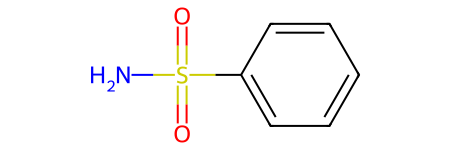

In [12]:
dm.to_mol(query)

In [10]:
search = {}
search["query"] = [int(x) for x in results]

In [11]:
sort = sorted([int(s) for s in results])
len(sort)

26301

In [13]:
import duckdb 
db = duckdb.connect()

In [14]:
res = db.execute(f"SELECT SMILES, num_ID FROM read_parquet($path) WHERE num_ID in $query", {"path":["test1/*.parquet"],  "query": sort}).df()

In [15]:
res[res["num_ID"].isin(sort)]

,SMILES,num_ID
0,Cc1ccc(cc1C)S(=O)(=O)N2CCN(CC2)C(=O)c3ccon3,19
1,c1cc(ccc1NC(=O)c2ccon2)S(=O)(=O)N3CCNCC3,36
2,c1cc(ccc1N)S(=O)(=O)N2CCN(CC2)C(=O)c3ccon3,37
3,CNS(=O)(=O)c1ccc(cc1)NC(=O)c2ccon2,41
4,Cc1ccc(c(c1)S(=O)(=O)N2CCN(CC2)C(=O)c3ccon3)C,49
...,...,...
26296,C[C@@H]1CCCN(C1)S(=O)(=O)c2ccc(cc2)NC(=O)[C@@H...,4172083
26297,C[C@H]1CCCN(C1)S(=O)(=O)c2ccc(cc2)NC(=O)[C@@H]...,4172084
26298,Cc1ccc(cc1NC(=O)[C@H]2CC(=O)OC23CCCC3)S(=O)(=O)N,4174135
26299,c1ccc(cc1)S(=O)(=O)N2CCC(CC2)NC(=O)[C@H]3CC(=O...,4174373


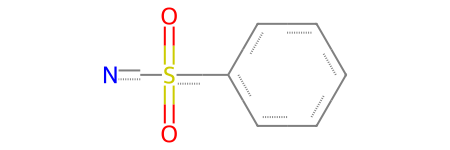

In [17]:
query_mol = Chem.MolFromSmarts(query)
def match_smiles(smi, query_mol=query_mol):
    mol = dm.to_mol(smi)
    if mol is None:
        return False
    return mol.HasSubstructMatch(query_mol)
query_mol

In [18]:
for smi in res["SMILES"].values:
    if match_smiles(smi):
        print(smi)

Cc1ccc(cc1C)S(=O)(=O)N2CCN(CC2)C(=O)c3ccon3
c1cc(ccc1NC(=O)c2ccon2)S(=O)(=O)N3CCNCC3
c1cc(ccc1N)S(=O)(=O)N2CCN(CC2)C(=O)c3ccon3
CNS(=O)(=O)c1ccc(cc1)NC(=O)c2ccon2
Cc1ccc(c(c1)S(=O)(=O)N2CCN(CC2)C(=O)c3ccon3)C
c1cc(ccc1NC(=O)c2ccon2)S(=O)(=O)N3CCCC3
c1cc(ccc1S(=O)(=O)N2CCN(CC2)C(=O)c3ccon3)Cl
c1cc(ccc1NC(=O)c2ccon2)S(=O)(=O)N3CCCCCC3
C[C@H]1CCCN(C1)S(=O)(=O)c2ccc(cc2)NC(=O)c3ccon3
CNS(=O)(=O)c1ccccc1NC(=O)c2ccon2
c1cc(c(cc1S(=O)(=O)N)O)NC(=O)c2ccon2
CNS(=O)(=O)c1cccc(c1)NC(=O)c2ccon2
c1cc(c(cc1S(=O)(=O)N)NC(=O)c2ccon2)Cl
c1cnn(c1)CC(=O)Nc2ccc(cc2)S(=O)(=O)N3CCOCC3
Cc1ccc(cc1C)S(=O)(=O)N2CCN(CC2)C(=O)Cn3cccn3
c1cnn(c1)CC(=O)Nc2ccc(cc2)S(=O)(=O)N3CCNCC3
CN(C)S(=O)(=O)c1ccc(cc1)NC(=O)Cn2cccn2
c1cnn(c1)CC(=O)N2CCN(CC2)S(=O)(=O)c3ccc(cc3)F
c1ccc(cc1)S(=O)(=O)N2CCN(CC2)C(=O)Cn3cccn3
Cc1ccc(cc1)S(=O)(=O)N2CCN(CC2)C(=O)Cn3cccn3
CN1CCN(CC1)S(=O)(=O)c2ccc(cc2)NC(=O)Cn3cccn3
C[C@@H]1CCCN(C1)S(=O)(=O)c2ccc(cc2)NC(=O)Cn3cccn3
c1ccc(cc1)S(=O)(=O)N2CCC(CC2)NC(=O)Cn3cccn3
CNS(=O)(=O)c1ccccc1NC(=O)Cn2cc

In [19]:
a = res.drop_duplicates(subset=["num_ID"])
#mols = dm.from_df(a, smiles_column="SMILES")
mask = dm.parallelized(partial(match_smiles, query_mol=query_mol), a["SMILES"], n_jobs=4, progress=False, scheduler="threads")

/home/ruite/miniforge3/envs/ai_factory/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


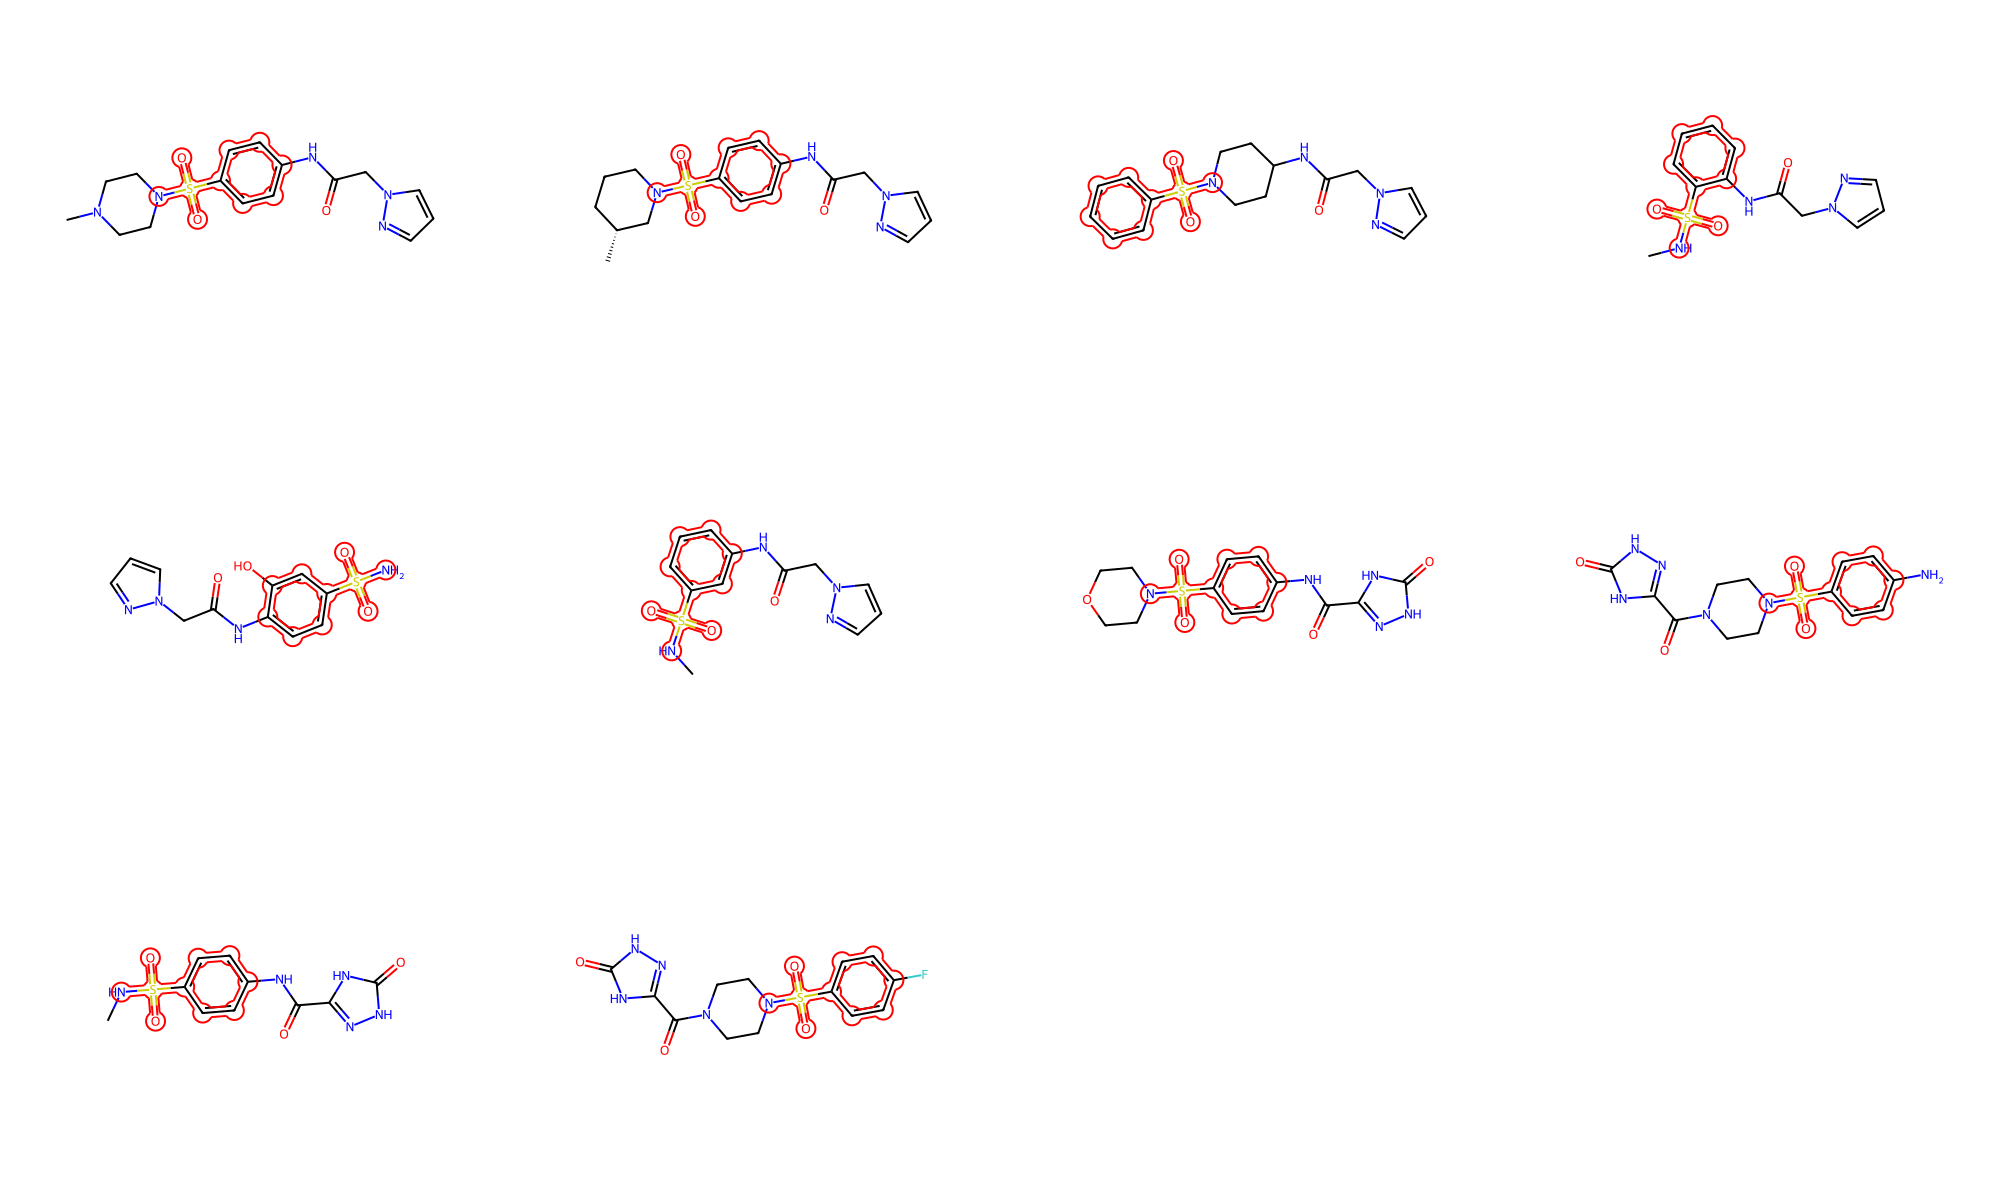

In [25]:
dm.lasso_highlight_image(list(a[mask]["SMILES"].values[20:30]), [query], mol_size=(500, 400), use_svg=False)

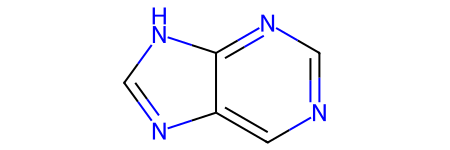

In [ ]:


p = Chem.MolFromSmiles('[nH]1cnc2cncnc21')
p

In [10]:
a = pd.Series({2:4,5:7})
a.rename("tanimoto")

2    4
5    7
Name: tanimoto, dtype: int64

### Generate conformers

In [3]:
import datamol as dm
from molfeat.trans.fp import FPVecTransformer
from rdkit import DataStructs

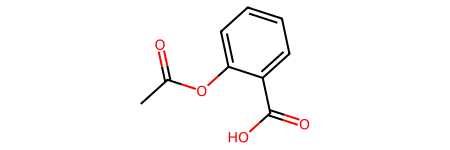

In [11]:
smi = "O=C(C)Oc1ccccc1C(=O)O"
mol = dm.to_mol(smi)
smi = dm.to_smiles(mol, canonical=True, isomeric=False)
mol = dm.to_mol(smi)
mol

In [1]:
120138771115 > 93848479020

True

In [22]:
a = dm.conformers.generate(mol, n_confs=10, align_conformers=True, minimize_energy=True)
conf = a.GetConformers()

In [ ]:
import numpy as np

def normalized_distances_to_reference(vectors, reference_idx=0):
    """
    1. Normalize features to comparable ranges
    2. Compute distances in normalized space
    """
    # Method A: Min-max normalization per feature
    min_vals = vectors.min(axis=0)
    max_vals = vectors.max(axis=0)
    range_vals = max_vals - min_vals
    range_vals[range_vals == 0] = 1  # Avoid division by zero
    normalized = (vectors - min_vals) / range_vals
    
    # Reference in normalized space
    ref_norm = normalized[reference_idx]
    
    # Distances in normalized space
    distances = np.sqrt(np.sum((normalized - ref_norm) ** 2, axis=1))
    ranking = np.argsort(distances)
    
    return distances, ranking, normalized

# Usage


# Example usage
vectors = np.array([
    [0, 10, 100],   # Small, medium, large counts
    [5, 20, 50],
    [1, 5, 200],
    [0, 0, 300]
])

distances, ranking, normalized = normalized_distances_to_reference(vectors, 0)

[  5  20 250]
[  5  20 250]


In [61]:
vectors.min(axis=0)

array([ 0,  0, 50])

### Ekaitz

In [3]:
mol1 = dm.to_mol("Cc1ncc(C[n+]2csc(CCO[P@@](=O)([O-])O[P@@](=O)([O-])O)c2C)c(N)n1")

In [5]:
mols2 = pd.read_csv("/home/ruite/Projects/AI factory/Drug database/LibMiner/clean/TPP_prot_nostereo_smiles.csv", index_col=[0,1])
mol = mols2["nostereo_SMILES"].to_list()
real_tani = 1 -dm.cdist([mol1], mol, fpSize=1024, radius=2)[0]
mols2["real_TANI"] = real_tani
len(real_tani[real_tani>0.6])

/home/ruite/miniforge3/envs/ai_factory/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


25

In [35]:
mols2[mols2["real_TANI"]>0.6]

nostereo_SMILES  \
Cc1ncc(C[n+]2csc(CCO[P@@](=O)([O-])O[P@@](=O)([... 1      Cc1ncc(C[n+]2csc(CCOP(=O)([O-])O)c2C)c(N)n1   
                                                   8   Cc1ncc(C[n+]2csc(CCOP(=O)([O-])[O-])c2C)c(N)n1   
                                                   9         Cc1ncc(C[n+]2csc(CCOP(=O)(O)O)c2C)c(N)n1   
                                                   14                  COCCc1sc[n+](Cc2cnc(C)nc2N)c1C   
                                                   24       Cc1ncc(C[n+]2csc(CCCOP(=O)(O)O)c2C)c(N)n1   
                                                   33       Cc1ncc(C[n+]2csc(CCOOP(=O)(O)O)c2C)c(N)n1   
                                                   36     Cc1ncc(C[n+]2csc(CCO[N+](=O)[O-])c2C)c(N)n1   

                                                           num_ID  Tanimoto  \
Cc1ncc(C[n+]2csc(CCO[P@@](=O)([O-])O[P@@](=O)([... 1   1488224413  0.872727   
                                                   8   1981819926  0.803571   
                                                   9   1991751702  0.803571   
                                                   14   411713376  0.709091   
                                                   24  2375253655  0.716667   
                                                   33  3083312351  0.716667   
                                                   36  1357338551  0.741379   

                                                       real_TANI  
Cc1ncc(C[n+]2csc(CCO[P@@](=O)([O-])O[P@@](=O)([... 1    0.872727  
                                                   8    0.803571  
                                                   9    0.803571  
                                                   14   0.709091  
                                                   24   0.716667  
                                                   33   0.716667  
                                                   36   0.741379

In [7]:
ekaitz_nostereo = pd.read_csv("/home/ruite/Projects/AI factory/Drug database/TPP_prot_nostereo_smiles_05.csv", index_col=[0,1])
mol3 = ekaitz_nostereo["nostereo_SMILES"].to_list()
real_tani = 1 -dm.cdist([mol1], mol3, fpSize=1024, radius=2)[0]
ekaitz_nostereo["real_TANI"] = real_tani
len(real_tani[real_tani>0.6])

117

In [21]:
ekaitz_nostereo[ekaitz_nostereo["num_ID"]== 176975579]

,,nostereo_SMILES,num_ID,Tanimoto,real_TANI


In [26]:
ekaitz_small = pd.read_csv("/home/ruite/Projects/AI factory/Drug database/TPP_prot_tmp_chunks_nostereo_smiles.csv", index_col=[0,1])
mol4 = ekaitz_small["nostereo_SMILES"].to_list()
real_tani = 1 -dm.cdist([mol1], mol4, fpSize=1024, radius=2)[0]
ekaitz_small["real_TANI"] = real_tani
len(real_tani[real_tani>0.6])

11

In [153]:
i = [4231330, 4264053, 5472299, 286843469, 311976766]
num2 = [x[0] for x in list(search_1.values())[0]]
num1 = [x[0] for x in list(search_2.values())[0]]
num1

[1334291592,
 1086440841,
 850795222,
 1030369735,
 823458741,
 925167662,
 909672834,
 1095089329,
 841842032,
 788812594,
 908740790,
 1096223919,
 1198251423,
 902262300,
 1258885897,
 1103797325,
 807660925,
 945906722,
 718526497,
 947579333,
 1158486299]

In [155]:
ekaitz_nostereo[ekaitz_nostereo["num_ID"].isin(num1)]

nostereo_SMILES  \
Cc1ncc(C[n+]2csc(CCO[P@@](=O)([O-])O[P@@](=O)([... 2766                C=CCOCCc1sc[n+](Cc2cnc(C)nc2N)c1C   
                                                   2794               Cc1ncc(C[n+]2csc(CCOCCO)c2C)c(N)n1   
                                                   2915              CC(=O)SCCc1sc[n+](Cc2cnc(C)nc2N)c1C   
                                                   2923                CC=COCCc1sc[n+](Cc2cnc(C)nc2N)c1C   
                                                   2928              Cc1ncc(C[n+]2csc(CCOCC=O)c2C)c(N)n1   
                                                   2966               Cc1ncc(C[n+]2csc(CCOCCN)c2C)c(N)n1   
                                                   3013  Cc1ncc(C[n+]2csc(CCO[N+](=O)[O-])c2C)c([NH-])n1   
                                                   3019          CC(=O)OCCc1sc[n+](Cc2cnc(C)nc2[NH-])c1C   
                                                   3223            Cc1ncc(C[n+]2csc(CCOC(N)=S)c2C)c(N)n1   
                                                   3349              CC(=O)OCCc1sc[n+](Cc2cnc(C)nc2N)c1C   
                                                   3364               Cc1ncc(C[n+]2csc(CCOCCF)c2C)c(N)n1   
                                                   3367           Cc1ncc(C[n+]2csc(CCC(C)(C)C)c2C)c(N)n1   
                                                   3390         CC[S+]([O-])CCc1sc[n+](Cc2cnc(C)nc2N)c1C   
                                                   3499                CCc1c(CCOC=O)sc[n+]1Cc1cnc(C)nc1N   
                                                   3590              CNC(=O)CCc1sc[n+](Cc2cnc(C)nc2N)c1C   
                                                   3724              CC(=O)NCCc1sc[n+](Cc2cnc(C)nc2N)c1C   
                                                   3899          Cc1ncc(C[n+]2csc(CCP(=O)(O)O)c2C)c(N)n1   
                                                   4574              Cc1ncc(C[n+]2csc(CC(O)CO)c2C)c(N)n1   
                                                   4732        Cc1ncc(C[n+]2csc(CC[S+](C)[O-])c2C)c(N)n1   
                                                   4785                  CCc1c(CCOC)sc[n+]1Cc1cnc(C)nc1N   
                                                   4812               Cc1ncc(C[n+]2csc(CCOC=O)c2C)c(N)n1   

                                                             num_ID  Tanimoto  \
Cc1ncc(C[n+]2csc(CCO[P@@](=O)([O-])O[P@@](=O)([... 2766   841842032  0.622951   
                                                   2794   850795222  0.650000   
                                                   2915   902262300  0.587302   
                                                   2923   908740790  0.612903   
                                                   2928   909672834  0.629032   
                                                   2966   925167662  0.633333   
                                                   3013   945906722  0.578125   
                                                   3019   947579333  0.538462   
                                                   3223  1030369735  0.650000   
                                                   3349  1086440841  0.677966   
                                                   3364  1095089329  0.622951   
                                                   3367  1096223919  0.593220   
                                                   3390  1103797325  0.580645   
                                                   3499  1158486299  0.522388   
                                                   3590  1198251423  0.587302   
                                                   3724  1258885897  0.587302   
                                                   3899  1334291592  0.689655   
                                                   4574   718526497  0.548387   
                                                   4732   788812594  0.616667   
                                                   4785   807660925  0.580645   
           

In [117]:
with open("hits.txt", "w") as w:
    for x, n in ekaitz_nostereo.sort_values("real_TANI", ascending=False)[["nostereo_SMILES", "num_ID"]].head(100).values:
        w.write(f"{x} {n}\n")

In [38]:
ekaitz_1 = pd.read_csv("/home/ruite/Projects/AI factory/Drug database/TPP_prot_test_db_nostereo_smiles.csv", index_col=[0,1])
mol3 = ekaitz_1["nostereo_SMILES"].to_list()
real_tani = 1 -dm.cdist([mol1], mol3, fpSize=1024, radius=2)[0]
ekaitz_1["real_TANI"] = real_tani
len(real_tani[real_tani>0.5])

9

In [ ]:
for x, a in search_3.items():
    i = [u[0] for u in a]
    f = ekaitz_nostereo[ekaitz_nostereo["num_ID"].isin(i)]
    l = f[f["real_TANI"]>0.5]
    if len(l):
        print("yes:", x, len(l))
    else:
        print("no:", x, len(l))

no: 71 0
yes: 1 14
no: 135 0
no: 62 0
no: 129 0
no: 64 0
no: 89 0
yes: 12 8
no: 46 0
no: 83 0
no: 30 0
no: 126 0
no: 90 0
no: 16 0
no: 73 0
no: 57 0
no: 61 0
no: 15 0
no: 87 0
no: 47 0
no: 29 0
no: 81 0
no: 25 0
no: 88 0
no: 49 0
no: 84 0
no: 106 0
no: 119 0
yes: 6 13
no: 118 0
no: 100 0
no: 112 0
no: 75 0
no: 105 0
no: 121 0
no: 22 0
no: 33 0
no: 124 0
no: 38 0
no: 138 0
no: 130 0
no: 70 0
no: 56 0
no: 136 0
yes: 10 26
no: 95 0
no: 128 0
no: 115 0
no: 93 0
no: 91 0
no: 40 0
no: 44 0
no: 101 0
no: 69 0
no: 77 0
no: 86 0
no: 55 0
no: 99 0
no: 67 0
no: 98 0
no: 17 0
no: 132 0
no: 137 0
no: 20 0
no: 94 0
no: 32 0
no: 103 0
yes: 3 9
no: 76 0
no: 27 0
no: 48 0
no: 36 0
no: 66 0
no: 109 0
no: 131 0
no: 127 0
no: 142 0
no: 43 0
no: 96 0
no: 120 0
no: 68 0
no: 97 0
yes: 11 33
no: 18 0
no: 123 0
no: 114 0
yes: 8 14
no: 21 0
no: 110 0
yes: 4 13
no: 79 0
no: 102 0
no: 58 0
no: 82 0
no: 80 0
no: 41 0
no: 134 0
no: 113 0
no: 37 0
no: 14 0
no: 24 0
no: 117 0
no: 53 0
no: 125 0
no: 13 0
yes: 0 17
no: